### 01 - Instalação (Bibliotecas)

In [ ]:
%pip install numpy
%pip install matplotlib

### 02 - Importação (Recursos)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print(f"Numpy Version: {np.__version__}")

### 03 - Preparação do CSV

In [13]:
try:
    data = np.genfromtxt("./kc_house_data.csv", delimiter=",", skip_header=1, usecols=(5,2))

    print(data)
except:
    print("Erro ao carregar o CSV!")

    exit()

[[  1180. 221900.]
 [  2570. 538000.]
 [   770. 180000.]
 ...
 [  1020. 402101.]
 [  1600. 400000.]
 [  1020. 325000.]]


### 04 - Preparação dos Dados

In [14]:
# Colunas relevantes para o cálculo.

X = data[:, 0] # SQFT Living.

y = data[:, 1] # Price.

X_2 = [X**2]

y_2 = [y**2]

xy = X * y

# Soma dos valores de cada coluna.

X_sum = np.sum(X)

y_sum = np.sum(y)

X_2_sum = np.sum(X_2)

y_2_sum = np.sum(y_2)

xy_sum = np.sum(xy)

# Quantidade de valores das colunas.

sample_length = len(X)

### 05 - Coeficientes do Cálculo de Regressão da Reta

In [15]:
# Coeficiente angular.

b = ((sample_length * xy_sum) - (X_sum * y_sum)) / ((sample_length * X_2_sum) - (X_sum ** 2))

# Intercepto.

a = (y_sum - (b * X_sum)) / sample_length

# Coeficiente de correlação.

r = ((sample_length * xy_sum) - (X_sum * y_sum)) / (np.sqrt((sample_length * X_2_sum) - (X_sum ** 2)) * np.sqrt((sample_length * y_2_sum) - (y_sum ** 2)))

# Coeficiente de determinação.

y_hat = a + (b * X)

y_mean = np.mean(y)

sq_reg = np.sum((y_hat - y_mean)**2)
sq_tot = np.sum((y - y_mean)**2)

r_2 = sq_reg / sq_tot

# Saída.

print(f"Equação da Reta (Y Hat): {a:.4f} + {b:.4f} * X")

print(f"\nCoeficiente de Correlação (R): {r:.4f}")

print(f"\nCoeficiente de Determinação (R²): {r_2:.4f}")

Equação da Reta (Y Hat): -43580.7431 + 280.6236 * X

Coeficiente de Correlação (R): 0.7020

Coeficiente de Determinação (R²): 0.4929


### 06 - Gráfico

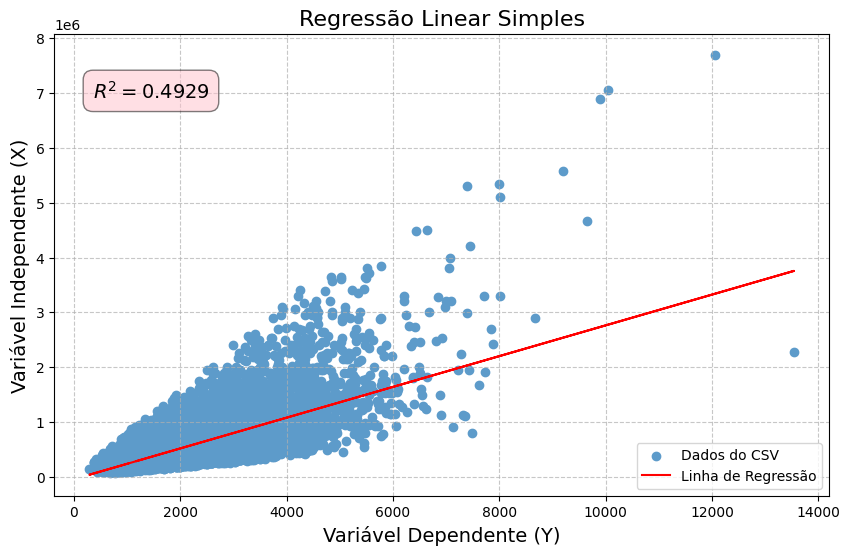

In [16]:
plt.figure(figsize=(10,6))

plt.scatter(X, y, color="#5D9BCA", label="Dados do CSV")

plt.plot(X, y_hat, color="red", label="Linha de Regressão")

plt.title("Regressão Linear Simples", fontsize=16)

plt.xlabel("Variável Dependente (Y)", fontsize=14)
plt.ylabel("Variável Independente (X)", fontsize=14)

plt.text(
  0.05,
  0.9,
  f"$R^2 = {r_2:.4f}$",
  transform=plt.gca().transAxes,
  fontsize=14,
  verticalalignment="top",
  bbox=dict(boxstyle="round, pad=0.5", fc="pink", alpha=0.5)
)

plt.legend()

plt.grid(True, linestyle="--", alpha=0.7)

plt.show()